In [1]:
!pip install koreanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split

df = pd.read_csv('hotel_bookings.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 29.4 MB/s eta 0:00:00


[Original] Total: 119390 records, Cancellation rate: 37.0%
[After dedup] Total: 87396 records, Cancellation rate: 27.5%
[lead_time <= 300 days] Total: 85110 records, Cancellation rate: 27.0%
[After stratified sampling] Total: 30000 records, Cancellation rate: 27.0%


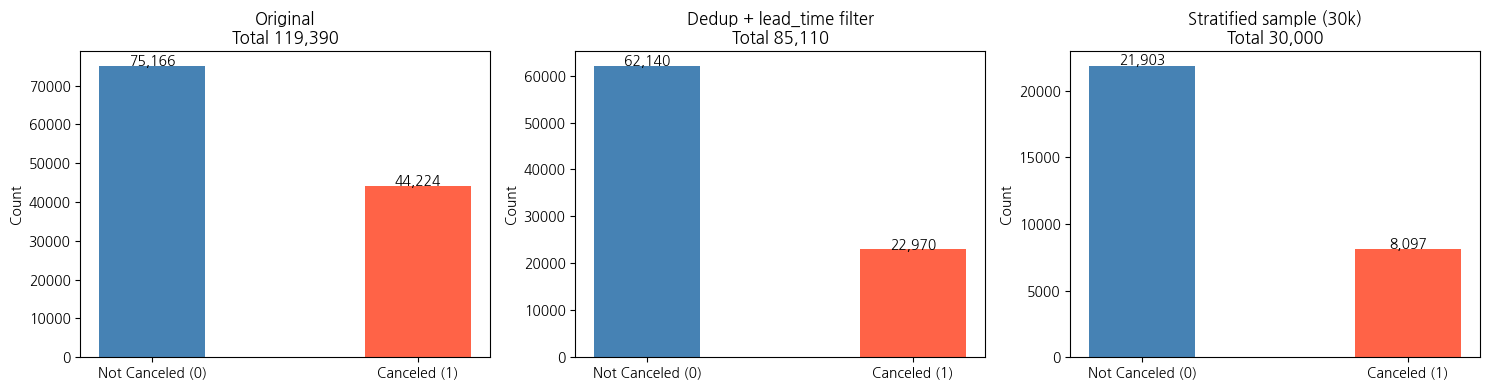

In [2]:
print(f"[Original] Total: {len(df)} records, Cancellation rate: {df['is_canceled'].mean()*100:.1f}%")

# 1. Remove duplicates
df_clean = df.drop_duplicates()
print(f"[After dedup] Total: {len(df_clean)} records, Cancellation rate: {df_clean['is_canceled'].mean()*100:.1f}%")

# 2. Remove entries where lead_time exceeds 300 days
df_clean = df_clean[df_clean['lead_time'] <= 300]
print(f"[lead_time <= 300 days] Total: {len(df_clean)} records, Cancellation rate: {df_clean['is_canceled'].mean()*100:.1f}%")

# 3. Stratified sampling of 30,000 records (preserve cancellation rate ratio)
df_sample, _ = train_test_split(df_clean, train_size=30000, stratify=df_clean['is_canceled'], random_state=42)
print(f"[After stratified sampling] Total: {len(df_sample)} records, Cancellation rate: {df_sample['is_canceled'].mean()*100:.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps = [
    (df, 'Original'),
    (df_clean, 'Dedup + lead_time filter'),
    (df_sample, 'Stratified sample (30k)')
]
for ax, (data, title) in zip(axes, steps):
    counts = data['is_canceled'].value_counts().sort_index()
    ax.bar(['Not Canceled (0)', 'Canceled (1)'], counts.values, color=['steelblue', 'tomato'], width=0.4)
    ax.set_title(f'{title}\nTotal {len(data):,}')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

# Feature Engineering

## Removed Features
| Feature | Reason |
|------|------|
| `arrival_date_day_of_month` | Noisy, no pattern with cancellation rate |
| `arrival_date_year` | Only 3 values, negligible difference in cancellation rate |
| `babies` | Sparse data |
| `company` | Too many missing values |
| `reservation_status` / `reservation_status_date` | Risk of data leakage |
| `deposit_type` | Non Refund 99.4% artifact, very few Refundable cases |
| `room_changed` | Data leakage — room is assigned at check-in, so canceled guests are always recorded as no change |
| `is_repeated_guest` | Correlation of 0.42 with `previous_bookings_not_canceled` (redundant); the latter has higher discriminative power for cancellation rate |
| `required_car_parking_spaces` | Suspected data leakage — 0% cancellation rate when parking is requested |

## Newly Created Features
| Feature | Description |
|------|------|
| `has_children` | 1 if children > 0 or babies > 0 |
| `is_domestic` | 1 if country is PRT (Portugal) |
| `has_prev_completed` | 1 if previous_bookings_not_canceled > 0 |
| `has_booking_changes` | 1 if booking_changes > 0 |

## Encoding
| Feature | Method |
|------|------|
| `hotel` | Label (City Hotel=0, Resort Hotel=1) |
| `arrival_date_month` | Convert to int (1~12) |
| `market_segment` | Label Encoding |
| `customer_type` | Label Encoding |


In [3]:
df_model = df_sample.copy()

# Create new features
df_model['has_children'] = ((df_model['children'] > 0) | (df_model['babies'] > 0)).astype(int)
df_model['is_domestic'] = (df_model['country'] == 'PRT').astype(int)
df_model['has_prev_completed'] = (df_model['previous_bookings_not_canceled'] > 0).astype(int)
df_model['has_booking_changes'] = (df_model['booking_changes'] > 0).astype(int)
df_model['lead_x_domestic'] = df_model['lead_time'] * df_model['is_domestic']
df_model['total_nights'] = df_model['stays_in_weekend_nights'] + df_model['stays_in_week_nights']

# Convert month to int
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_model['arrival_date_month'] = df_model['arrival_date_month'].map(month_map)

# Label Encoding
hotel_map = {'City Hotel': 0, 'Resort Hotel': 1}
df_model['hotel'] = df_model['hotel'].map(hotel_map)

market_map = {
    'Online TA': 0, 'Offline TA/TO': 1, 'Direct': 2,
    'Corporate': 3, 'Groups': 4, 'Complementary': 5, 'Aviation': 6
}
df_model['market_segment'] = df_model['market_segment'].map(market_map)

customer_map = {
    'Transient': 0, 'Transient-Party': 1, 'Contract': 2, 'Group': 3
}
df_model['customer_type'] = df_model['customer_type'].map(customer_map)

# Segments for analysis/visualization (not included in model training)
df_model['lead_segment'] = pd.cut(
    df_model['lead_time'],
    bins=[-1, 14, 90, 300],
    labels=['Impulsive (0-14d)', 'Standard (15-90d)', 'Planned (91-300d)']
)
df_model['domestic_segment'] = df_model['is_domestic'].map({1: 'Domestic (PRT)', 0: 'International'})
df_model['season_segment'] = df_model['arrival_date_month'].apply(
    lambda x: 'Peak Season (Jun-Sep)' if x in [6, 7, 8, 9] else 'Off Season'
)
df_model['price_segment'] = pd.cut(
    df_model['adr'],
    bins=[-1, 72, 134, 500],
    labels=['Low (~72)', 'Mid (72~134)', 'High (134~)']
)

# Final feature selection
features = [
    'lead_time', 'hotel', 'total_of_special_requests',
    'is_domestic', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'arrival_date_month', 'arrival_date_week_number', 'market_segment',
    'has_children', 'previous_cancellations', 'adr', 'customer_type',
    'has_prev_completed', 'has_booking_changes',
    'lead_x_domestic', 'total_nights',
]

X = df_model[features]
y = df_model['is_canceled']

print(f"Number of features: {len(features)}")
print(f"Number of data points: {len(X)}")
print(X.dtypes)

Number of features: 17
Number of data points: 30000
lead_time                      int64
hotel                          int64
total_of_special_requests      int64
is_domestic                    int64
stays_in_weekend_nights        int64
stays_in_week_nights           int64
arrival_date_month             int64
arrival_date_week_number       int64
market_segment               float64
has_children                   int64
previous_cancellations         int64
adr                          float64
customer_type                  int64
has_prev_completed             int64
has_booking_changes            int64
lead_x_domestic                int64
total_nights                   int64
dtype: object


# Model Training and Evaluation

## Model Selection Summary

| Attempt | F1 | ROC-AUC | Notes |
|------|-----|---------|------|
| RF Baseline | 0.6102 | 0.8523 | Default settings |
| XGBoost Baseline | 0.6011 | 0.8530 | Default settings |
| RF + class_weight=balanced | 0.6337 | 0.8549 | Weighted minority class |
| RF RandomizedSearch + balanced | 0.6400 | 0.8586 | Hyperparameter search |
| XGBoost tuned (lr=0.03, threshold=0.55) | 0.6428 | 0.8594 | With early stopping |
| **RF balanced + threshold=0.4** | **0.6475** | 0.8549 | **Final selection** |

## Final Model: Random Forest (class_weight=balanced, threshold=0.4)
- Best F1 performance
- Easier to interpret than XGBoost
- threshold 0.4: More aggressive cancellation prediction to improve recall


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Train/Test Split (80/20, preserve cancellation rate ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train)} records / Test: {len(X_test)} records")
print(f"Train cancellation rate: {y_train.mean()*100:.1f}% / Test cancellation rate: {y_test.mean()*100:.1f}%")

Train: 24000 records / Test: 6000 records
Train cancellation rate: 27.0% / Test cancellation rate: 27.0%


In [5]:
# Baseline comparison
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("=" * 40)
print("Random Forest Baseline")
print(f"  F1-score : {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print("=" * 40)
print("XGBoost Baseline")
print(f"  F1-score : {f1_score(y_test, xgb_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print("=" * 40)

Random Forest Baseline
  F1-score : 0.6066
  ROC-AUC  : 0.8517
XGBoost Baseline
  F1-score : 0.6038
  ROC-AUC  : 0.8534


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# beta=0.5 → Emphasize Precision
precision_scorer = make_scorer(fbeta_score, beta=0.5)

param_dist = {
    'n_estimators': range(100, 600, 50),
    'max_depth': range(5, 35, 5),
    'min_samples_split': range(2, 12, 2),
    'min_samples_leaf': range(1, 6),
}

rs = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_dist,
    n_iter=50,
    cv=5,
    scoring=precision_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rs.fit(X_train, y_train)

print(f"Best parameters: {rs.best_params_}")
print(f"CV Fbeta(0.5)-score: {rs.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
# Final model: Apply Precision-focused tuning results
final_model = rs.best_estimator_
final_proba = final_model.predict_proba(X_test)[:, 1]

# Threshold search
from sklearn.metrics import precision_score, recall_score

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)
for t in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]:
    pred_t = (final_proba >= t).astype(int)
    p = precision_score(y_test, pred_t)
    r = recall_score(y_test, pred_t)
    f = f1_score(y_test, pred_t)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Set threshold after decision
THRESHOLD = 0.55
final_pred = (final_proba >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14)

# Classification Report visualization
report = classification_report(y_test, final_pred, target_names=['Not Canceled', 'Canceled'], output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:2][['precision', 'recall', 'f1-score']]

x = np.arange(len(report_df.columns))
width = 0.3
for i, (idx, row) in enumerate(report_df.iterrows()):
    axes[1].bar(x + i * width, row.values, width=width, label=idx)

axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(['Precision', 'Recall', 'F1-score'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Classification Report', fontsize=14)
axes[1].legend()
for i, (idx, row) in enumerate(report_df.iterrows()):
    for j, v in enumerate(row.values):
        axes[1].text(j + i * width, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle(f'Final Model Performance (threshold={THRESHOLD})  |  F1: {f1_score(y_test, final_pred):.4f}  |  ROC-AUC: {roc_auc_score(y_test, final_proba):.4f}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Remove only data leakage columns
drop_cols = ['is_canceled', 'reservation_status', 'reservation_status_date']
df_all = df_sample.drop(columns=drop_cols).copy()

# Label encode all string columns
for col in df_all.select_dtypes(include='object').columns:
    df_all[col] = LabelEncoder().fit_transform(df_all[col].astype(str))

X_all = df_all
y_all = df_sample['is_canceled']

X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

rf_all = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
rf_all.fit(X_all_train, y_all_train)
proba_all = rf_all.predict_proba(X_all_test)[:, 1]

print(f"Number of features: {X_all.shape[1]}")
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)
for t in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]:
    pred_t = (proba_all >= t).astype(int)
    p = precision_score(y_all_test, pred_t)
    r = recall_score(y_all_test, pred_t)
    f = f1_score(y_all_test, pred_t)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

print(f"\nROC-AUC: {roc_auc_score(y_all_test, proba_all):.4f}")

# Feature Engineering Improvement

## Limitations of Initial Feature Selection
Training with all features yielded Precision 0.755 (vs 0.666 with selected features), a significant performance gap.
Feature importance analysis revealed that some features we removed/simplified were actually important:

| Feature | Importance Rank | Issue |
|------|----------|------|
| `country` | 2nd (0.115) | Binarizing to `is_domestic` lost country-level patterns |
| `agent` | 4th (0.071) | Removed due to many missing values, but actually important |

## Improvement Direction
- `agent` → Restore by filling NaN with 0 (represents direct bookings without an agent)
- `country` → Restore by grouping into top 10 countries + Other (resolves 177-cardinality issue)


In [ ]:
df_model2 = df_sample.copy()

# Create existing features
df_model2['has_children'] = ((df_model2['children'] > 0) | (df_model2['babies'] > 0)).astype(int)
df_model2['is_domestic'] = (df_model2['country'] == 'PRT').astype(int)
df_model2['has_prev_completed'] = (df_model2['previous_bookings_not_canceled'] > 0).astype(int)
df_model2['has_booking_changes'] = (df_model2['booking_changes'] > 0).astype(int)
df_model2['lead_x_domestic'] = df_model2['lead_time'] * df_model2['is_domestic']
df_model2['total_nights'] = df_model2['stays_in_weekend_nights'] + df_model2['stays_in_week_nights']

# Restore agent: fill NaN with 0
df_model2['agent'] = df_model2['agent'].fillna(0)

# Restore country: top 10 countries + Other
top10 = df_model2['country'].value_counts().head(10).index
df_model2['country_group'] = df_model2['country'].apply(lambda x: x if x in top10 else 'Other')
country_map = {c: i for i, c in enumerate(df_model2['country_group'].unique())}
df_model2['country_group'] = df_model2['country_group'].map(country_map)

# Convert month to int
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_model2['arrival_date_month'] = df_model2['arrival_date_month'].map(month_map)

# Label Encoding
df_model2['hotel'] = df_model2['hotel'].map({'City Hotel': 0, 'Resort Hotel': 1})
df_model2['market_segment'] = df_model2['market_segment'].map({
    'Online TA': 0, 'Offline TA/TO': 1, 'Direct': 2,
    'Corporate': 3, 'Groups': 4, 'Complementary': 5, 'Aviation': 6
})
df_model2['customer_type'] = df_model2['customer_type'].map({
    'Transient': 0, 'Transient-Party': 1, 'Contract': 2, 'Group': 3
})

# Segments for visualization
df_model2['lead_segment'] = pd.cut(
    df_model2['lead_time'],
    bins=[-1, 14, 90, 300],
    labels=['Impulsive (0-14d)', 'Standard (15-90d)', 'Planned (91-300d)']
)
df_model2['domestic_segment'] = df_model2['is_domestic'].map({1: 'Domestic (PRT)', 0: 'International'})
df_model2['season_segment'] = df_model2['arrival_date_month'].apply(
    lambda x: 'Peak Season (Jun-Sep)' if x in [6, 7, 8, 9] else 'Off Season'
)
df_model2['price_segment'] = pd.cut(
    df_model2['adr'],
    bins=[-1, 72, 134, 500],
    labels=['Low (~72)', 'Mid (72~134)', 'High (134~)']
)

features2 = [
    'lead_time', 'hotel', 'total_of_special_requests',
    'is_domestic', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'arrival_date_month', 'arrival_date_week_number', 'market_segment',
    'has_children', 'previous_cancellations', 'adr', 'customer_type',
    'has_prev_completed', 'has_booking_changes', 'lead_x_domestic', 'total_nights',
    'agent', 'country_group',
]

X2 = df_model2[features2]
y2 = df_model2['is_canceled']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

rf2 = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
rf2.fit(X2_train, y2_train)
proba2 = rf2.predict_proba(X2_test)[:, 1]

print(f"Number of features: {len(features2)}")
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)
for t in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]:
    pred_t = (proba2 >= t).astype(int)
    p = precision_score(y2_test, pred_t)
    r = recall_score(y2_test, pred_t)
    f = f1_score(y2_test, pred_t)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

print(f"\nROC-AUC: {roc_auc_score(y2_test, proba2):.4f}")

# Final Model Analysis


In [ ]:
# Feature importance
feat_imp = pd.Series(rf2.feature_importances_, index=features2).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp.index, feat_imp.values, color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)')
for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Compare actual vs predicted cancellation rate by segment
THRESHOLD = 0.5
final_pred2 = (proba2 >= THRESHOLD).astype(int)

segments = ['lead_segment', 'domestic_segment', 'season_segment', 'price_segment']
titles = ['Lead Time Segment', 'Domestic/International', 'Season', 'Price Range']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, seg, title in zip(axes.flatten(), segments, titles):
    seg_data = df_model2.loc[X2_test.index].copy()
    seg_data['actual'] = y2_test.values
    seg_data['predicted'] = final_pred2

    actual_rate = seg_data.groupby(seg)['actual'].mean() * 100
    pred_rate = seg_data.groupby(seg)['predicted'].mean() * 100

    x = range(len(actual_rate))
    ax.bar([i - 0.2 for i in x], actual_rate.values, width=0.4, label='Actual Cancellation Rate', color='steelblue')
    ax.bar([i + 0.2 for i in x], pred_rate.values, width=0.4, label='Predicted Cancellation Rate', color='tomato')
    ax.set_xticks(list(x))
    ax.set_xticklabels(actual_rate.index, rotation=15)
    ax.set_title(title)
    ax.set_ylabel('Cancellation Rate (%)')
    ax.legend()

plt.suptitle('Actual vs Predicted Cancellation Rate by Segment', fontsize=14)
plt.tight_layout()
plt.show()